# Alpha 0.2 최대 40 Epoch + Early Stopping 비교 실험

`node-2-alpha02.ipynb`를 기반으로 다음 두 모델을 새로 학습합니다.

1. RotationAug + MixUp (`alpha=0.2`)
2. RotationAug + CutMix (`alpha=0.2`)

최대 epoch는 40이며, Ex02와 같은 방식으로 validation loss가 10회 연속
충분히 개선되지 않으면 조기 종료합니다.

- 개선 조건: `val_loss < best_val_loss - 0.001`
- patience: `10`
- 기존 노트북과 결과 폴더는 읽기만 하고 수정하지 않음
- 신규 결과 폴더: `results_resnet50_aug_alpha02_epoch40_patience10/`

> 실행 전 **커널을 재시작하고 위에서부터 순서대로 실행**하세요.


## 1. 환경 초기화와 공통 설정

기존 20 epoch 실험과 공정하게 비교하기 위해 seed, batch size, optimizer,
learning rate, 데이터 분할을 유지합니다. `max_epochs=40`은 상한이며,
patience 조건에 걸리면 실제 학습 epoch는 40보다 작을 수 있습니다.


In [1]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder


gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SEED = 42
MAX_EPOCHS = 40
PATIENCE = 10
MIN_DELTA = 0.001
BATCH_SIZE = 16
LEARNING_RATE = 0.001
MIX_ALPHA = 0.2
NUM_WORKERS = 2
COOLDOWN_EVERY_EPOCHS = 5
COOLDOWN_SECONDS = 60

DATASET_DIR = Path("~/datasets/stanfordimagenetdogs/Images").expanduser()
RESULT_DIR = Path("results_resnet50_aug_alpha02_epoch40_patience10")
HISTORY_DIR = RESULT_DIR / "histories"
ORIGINAL_RESULT_DIR = Path("results_resnet50_aug")
ALPHA02_20_RESULT_DIR = Path("results_resnet50_aug_alpha02")

RESULT_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
print(f"Device: {DEVICE}")
print(f"New 40-epoch results: {RESULT_DIR.resolve()}")
print(f"Alpha 1.0 20-epoch results (read only): {ORIGINAL_RESULT_DIR.resolve()}")
print(f"Alpha 0.2 20-epoch results (read only): {ALPHA02_20_RESULT_DIR.resolve()}")


Device: cuda
New 40-epoch results: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex03/results_resnet50_aug_alpha02_epoch40_patience10
Alpha 1.0 20-epoch results (read only): /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex03/results_resnet50_aug
Alpha 0.2 20-epoch results (read only): /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex03/results_resnet50_aug_alpha02


## 2. 동일한 데이터 분할과 RotationAug transform

validation에는 augmentation을 적용하지 않습니다. 두 신규 모델의
main 입력 shape은 모두 `[batch, 3, 224, 224]`입니다.


In [2]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"데이터셋을 찾을 수 없습니다: {DATASET_DIR}"
    )


def base_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5],
        ),
    ])


def augment_rotationaug():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=5),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
        ),
    ])


def rotationaug_train_transform():
    return transforms.Compose([
        *augment_rotationaug().transforms,
        *base_transform().transforms,
    ])


full_dataset = ImageFolder(root=DATASET_DIR, transform=base_transform())
total_size = len(full_dataset)
train_size = int(0.583 * total_size)
val_size = total_size - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=split_generator,
)

class_names = full_dataset.classes
num_classes = len(class_names)


def indices_fingerprint(indices):
    index_array = np.asarray(list(indices), dtype=np.int64)
    return hashlib.sha256(index_array.tobytes()).hexdigest()


train_indices_sha256 = indices_fingerprint(train_subset.indices)
val_indices_sha256 = indices_fingerprint(val_subset.indices)

print(f"Classes: {num_classes}")
print(f"Train: {len(train_subset):,} | Validation: {len(val_subset):,}")
print(f"Train indices SHA256: {train_indices_sha256}")
print(f"Validation indices SHA256: {val_indices_sha256}")


Classes: 120
Train: 11,998 | Validation: 8,582
Train indices SHA256: 77811abc456327ae4a99911df61fc926fd75541cedff92bdda2aef045a247492
Validation indices SHA256: c718b1070073d063d393f0d926409ad57a9e70b8534c5212d9a04bf3ca2c1ad1


In [3]:
def make_loader(subset, is_validation=False, seed=SEED):
    dataset_copy = copy.copy(subset.dataset)
    dataset_copy.transform = (
        base_transform()
        if is_validation
        else rotationaug_train_transform()
    )
    isolated_subset = Subset(dataset_copy, subset.indices)
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        isolated_subset,
        batch_size=BATCH_SIZE,
        shuffle=not is_validation,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )


val_loader = make_loader(val_subset, is_validation=True)
sample_loader = make_loader(train_subset)
sample_images, sample_labels = next(iter(sample_loader))

assert sample_images.shape[1:] == (3, 224, 224)
print(f"Batch shape: {sample_images.shape}")
del sample_images, sample_labels, sample_loader


Batch shape: torch.Size([16, 3, 224, 224])


## 3. 동일한 초기 모델과 fingerprint

pretrained ResNet-50과 새 FC layer를 한 번 초기화하고, MixUp/CutMix 모델이
완전히 같은 `state_dict`에서 출발하도록 fingerprint를 검사합니다.


In [4]:
set_seed()
base_model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)
base_model.fc = nn.Linear(base_model.fc.in_features, num_classes)
initial_model_state = copy.deepcopy(base_model.state_dict())
del base_model


def state_dict_fingerprint(state_dict):
    digest = hashlib.sha256()
    for name in sorted(state_dict):
        tensor = state_dict[name].detach().cpu().contiguous()
        digest.update(name.encode("utf-8"))
        digest.update(str(tensor.dtype).encode("utf-8"))
        digest.update(np.asarray(tensor.shape, dtype=np.int64).tobytes())
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()


initial_model_sha256 = state_dict_fingerprint(initial_model_state)


def create_model():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(initial_model_state)
    return model


verification_model_a = create_model()
verification_model_b = create_model()
assert all(
    torch.equal(
        verification_model_a.state_dict()[name],
        verification_model_b.state_dict()[name],
    )
    for name in initial_model_state
)
assert state_dict_fingerprint(
    verification_model_a.state_dict()
) == initial_model_sha256
assert state_dict_fingerprint(
    verification_model_b.state_dict()
) == initial_model_sha256

del verification_model_a, verification_model_b
gc.collect()

print(f"Initial model SHA256: {initial_model_sha256}")
print("두 신규 모델의 초기 state_dict 동일성 검사를 통과했습니다.")


Initial model SHA256: 0d7d077cf589e581e6b94d03e07a85d3911a46f683b9972684498327d005c960
두 신규 모델의 초기 state_dict 동일성 검사를 통과했습니다.


## 4. Alpha 0.2 MixUp/CutMix

`alpha=0.2`인 Beta 분포는 0과 1 근처의 혼합 비율이 자주 선택됩니다.
이는 `alpha=1.0`보다 두 이미지가 50:50에 가깝게 섞이는 빈도를 낮춥니다.


In [5]:
def mixup_batch(images, labels, alpha):
    lam = float(np.random.beta(alpha, alpha))
    indices = torch.randperm(images.size(0), device=images.device)
    mixed_images = lam * images + (1.0 - lam) * images[indices]
    return mixed_images, labels, labels[indices], lam


def cutmix_batch(images, labels, alpha):
    lam = float(np.random.beta(alpha, alpha))
    indices = torch.randperm(images.size(0), device=images.device)

    height, width = images.shape[-2:]
    cut_ratio = np.sqrt(1.0 - lam)
    cut_width = int(width * cut_ratio)
    cut_height = int(height * cut_ratio)

    center_x = torch.randint(width, (1,), device=images.device).item()
    center_y = torch.randint(height, (1,), device=images.device).item()

    x1 = max(center_x - cut_width // 2, 0)
    x2 = min(center_x + cut_width // 2, width)
    y1 = max(center_y - cut_height // 2, 0)
    y2 = min(center_y + cut_height // 2, height)

    mixed_images = images.clone()
    mixed_images[:, :, y1:y2, x1:x2] = images[
        indices, :, y1:y2, x1:x2
    ]

    replaced_ratio = ((x2 - x1) * (y2 - y1)) / (width * height)
    adjusted_lam = float(1.0 - replaced_ratio)
    assert 0.0 <= adjusted_lam <= 1.0

    return mixed_images, labels, labels[indices], adjusted_lam


test_images = torch.randn(4, 3, 224, 224, device=DEVICE)
test_labels = torch.arange(4, device=DEVICE)
_, _, _, mixup_lam = mixup_batch(test_images, test_labels, MIX_ALPHA)
_, _, _, cutmix_lam = cutmix_batch(test_images, test_labels, MIX_ALPHA)
assert 0.0 <= mixup_lam <= 1.0
assert 0.0 <= cutmix_lam <= 1.0
del test_images, test_labels


## 5. Validation Loss 기준 Early Stopping

분류 정확도가 아니라 validation loss를 기준으로 patience를 계산합니다.
Cross Entropy loss는 정답 확률의 확신도까지 반영하므로, accuracy가 같아도
과도하게 확신하는 오답이 늘면 loss가 악화될 수 있습니다.


In [6]:
def evaluate(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            correct += outputs.argmax(dim=1).eq(labels).sum().item()
            total += batch_size

    return running_loss / total, 100.0 * correct / total


def train_experiment_with_early_stopping(
    model,
    train_loader,
    val_loader,
    experiment,
):
    set_seed(experiment["seed"])
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

    history = {
        "experiment": experiment["name"],
        "seed": experiment["seed"],
        "max_epochs": experiment["max_epochs"],
        "patience": experiment["patience"],
        "min_delta": experiment["min_delta"],
        "mix_alpha": experiment["mix_alpha"],
        "augmentation": experiment["augmentation"],
        "batch_mix": experiment["batch_mix"],
        "initial_model_sha256": initial_model_sha256,
        "train_indices_sha256": train_indices_sha256,
        "val_indices_sha256": val_indices_sha256,
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    best_val_loss = float("inf")
    best_loss_epoch = 0
    patience_counter = 0

    for epoch in range(1, experiment["max_epochs"] + 1):
        model.train()
        running_loss = 0.0
        weighted_correct = 0.0
        total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if experiment["batch_mix"] == "mixup":
                model_images, labels_a, labels_b, lam = mixup_batch(
                    images, labels, experiment["mix_alpha"]
                )
            elif experiment["batch_mix"] == "cutmix":
                model_images, labels_a, labels_b, lam = cutmix_batch(
                    images, labels, experiment["mix_alpha"]
                )
            else:
                raise ValueError("batch_mix must be mixup or cutmix")

            optimizer.zero_grad()
            outputs = model(model_images)
            loss = (
                lam * criterion(outputs, labels_a)
                + (1.0 - lam) * criterion(outputs, labels_b)
            )
            loss.backward()
            optimizer.step()

            predicted = outputs.argmax(dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            weighted_correct += (
                lam * predicted.eq(labels_a).sum().item()
                + (1.0 - lam) * predicted.eq(labels_b).sum().item()
            )
            total += batch_size

        train_loss = running_loss / total
        train_accuracy = 100.0 * weighted_correct / total
        val_loss, val_accuracy = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"[{experiment['name']}] Epoch "
            f"{epoch:02d}/{experiment['max_epochs']} | "
            f"train loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.2f}% | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_accuracy:.2f}%"
        )

        if val_loss < best_val_loss - experiment["min_delta"]:
            best_val_loss = val_loss
            best_loss_epoch = epoch
            patience_counter = 0
            print(
                f"  Validation loss improved: {best_val_loss:.4f} "
                f"(best epoch {best_loss_epoch})"
            )
        else:
            patience_counter += 1
            print(
                f"  Early stopping counter: "
                f"{patience_counter}/{experiment['patience']}"
            )

            if patience_counter >= experiment["patience"]:
                print(
                    f"Early stopping at epoch {epoch}. "
                    f"Best validation loss epoch: {best_loss_epoch}"
                )
                break

        if (
            epoch % COOLDOWN_EVERY_EPOCHS == 0
            and epoch < experiment["max_epochs"]
        ):
            print(
                f"GPU 냉각을 위해 {COOLDOWN_SECONDS}초간 대기합니다. "
                f"({epoch}/{experiment['max_epochs']} epoch 완료)"
            )
            time.sleep(COOLDOWN_SECONDS)

    history["actual_epochs"] = len(history["val_loss"])
    history["early_stopped"] = (
        history["actual_epochs"] < experiment["max_epochs"]
    )
    history["best_loss_epoch"] = best_loss_epoch
    history["best_val_loss"] = best_val_loss
    history["val_accuracy_at_best_loss"] = (
        history["val_accuracy"][best_loss_epoch - 1]
    )
    return history


## 6. 신규 실험 설정과 독립 저장


In [7]:
EXPERIMENTS_ALPHA02_40 = [
    {
        "name": "rotationaug_mixup_alpha0.2_max40_patience10",
        "augmentation": "rotationaug",
        "batch_mix": "mixup",
        "mix_alpha": MIX_ALPHA,
        "seed": SEED,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
    },
    {
        "name": "rotationaug_cutmix_alpha0.2_max40_patience10",
        "augmentation": "rotationaug",
        "batch_mix": "cutmix",
        "mix_alpha": MIX_ALPHA,
        "seed": SEED,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
    },
]

experiment_config = {
    "model": "resnet50",
    "weights": "IMAGENET1K_V1",
    "dataset": str(DATASET_DIR),
    "num_classes": num_classes,
    "train_size": len(train_subset),
    "validation_size": len(val_subset),
    "image_size": [224, 224],
    "normalization_mean": [0.5, 0.5, 0.5],
    "normalization_std": [0.5, 0.5, 0.5],
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "min_delta": MIN_DELTA,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "optimizer": "SGD",
    "learning_rate": LEARNING_RATE,
    "mix_alpha": MIX_ALPHA,
    "initial_model_sha256": initial_model_sha256,
    "train_indices_sha256": train_indices_sha256,
    "val_indices_sha256": val_indices_sha256,
    "experiments": EXPERIMENTS_ALPHA02_40,
}

with (RESULT_DIR / "experiment_config.json").open("w", encoding="utf-8") as file:
    json.dump(experiment_config, file, ensure_ascii=False, indent=2)


def history_matches_experiment(history, experiment):
    actual_epochs = len(history.get("val_accuracy", []))
    return (
        1 <= actual_epochs <= experiment["max_epochs"]
        and history.get("actual_epochs") == actual_epochs
        and history.get("max_epochs") == experiment["max_epochs"]
        and history.get("patience") == experiment["patience"]
        and history.get("min_delta") == experiment["min_delta"]
        and history.get("seed") == experiment["seed"]
        and history.get("mix_alpha") == experiment["mix_alpha"]
        and history.get("augmentation") == experiment["augmentation"]
        and history.get("batch_mix") == experiment["batch_mix"]
        and history.get("initial_model_sha256") == initial_model_sha256
        and history.get("train_indices_sha256") == train_indices_sha256
        and history.get("val_indices_sha256") == val_indices_sha256
    )


def histories_to_dataframe(histories):
    rows = []
    for experiment_name, history in histories.items():
        for epoch_index in range(len(history["val_accuracy"])):
            rows.append({
                "experiment": experiment_name,
                "epoch": epoch_index + 1,
                "seed": history["seed"],
                "mix_alpha": history["mix_alpha"],
                "augmentation": history["augmentation"],
                "batch_mix": history["batch_mix"],
                "max_epochs": history["max_epochs"],
                "patience": history["patience"],
                "train_loss": history["train_loss"][epoch_index],
                "train_accuracy": history["train_accuracy"][epoch_index],
                "val_loss": history["val_loss"][epoch_index],
                "val_accuracy": history["val_accuracy"][epoch_index],
            })
    return pd.DataFrame(rows)


def build_new_summary(histories):
    rows = []
    for experiment_name, history in histories.items():
        best_acc_index = int(np.argmax(history["val_accuracy"]))
        rows.append({
            "experiment": experiment_name,
            "batch_mix": history["batch_mix"],
            "mix_alpha": history["mix_alpha"],
            "max_epochs": history["max_epochs"],
            "actual_epochs": history["actual_epochs"],
            "patience": history["patience"],
            "early_stopped": history["early_stopped"],
            "best_loss_epoch": history["best_loss_epoch"],
            "best_val_loss": history["best_val_loss"],
            "val_accuracy_at_best_loss": (
                history["val_accuracy_at_best_loss"]
            ),
            "best_acc_epoch": best_acc_index + 1,
            "best_val_accuracy": history["val_accuracy"][best_acc_index],
            "final_val_accuracy": history["val_accuracy"][-1],
            "final_val_loss": history["val_loss"][-1],
        })
    return pd.DataFrame(rows)


def save_new_results(histories):
    history_df = histories_to_dataframe(histories)
    summary_df = build_new_summary(histories)
    history_df.to_csv(RESULT_DIR / "training_history.csv", index=False)
    summary_df.to_csv(RESULT_DIR / "experiment_summary.csv", index=False)
    return history_df, summary_df


## 7. Alpha 0.2 두 모델 학습

각 모델은 새로운 ResNet-50과 optimizer로 시작합니다. 이미 완료된 신규
history가 현재 설정 및 fingerprint와 모두 일치하면 해당 모델만 건너뜁니다.


In [8]:
alpha02_40_histories = {}

for experiment in EXPERIMENTS_ALPHA02_40:
    experiment_name = experiment["name"]
    history_path = HISTORY_DIR / f"{experiment_name}.pt"

    if history_path.exists():
        saved_history = torch.load(history_path, map_location="cpu")
        if history_matches_experiment(saved_history, experiment):
            alpha02_40_histories[experiment_name] = saved_history
            print(f"[SKIP] {experiment_name}: 검증된 결과를 불러왔습니다.")
            save_new_results(alpha02_40_histories)
            continue

        print(
            f"[RESTART] {experiment_name}: 저장 결과의 설정 또는 "
            "fingerprint가 현재 실험과 다릅니다."
        )

    print(f"\n{'=' * 75}")
    print(
        f"Start: {experiment_name} | "
        f"batch_mix={experiment['batch_mix']} | "
        f"alpha={experiment['mix_alpha']} | "
        f"max_epochs={experiment['max_epochs']} | "
        f"patience={experiment['patience']}"
    )
    print(f"{'=' * 75}")

    train_loader = make_loader(
        train_subset,
        is_validation=False,
        seed=experiment["seed"],
    )
    model = create_model()
    assert state_dict_fingerprint(model.state_dict()) == initial_model_sha256

    history = train_experiment_with_early_stopping(
        model,
        train_loader,
        val_loader,
        experiment,
    )

    assert history_matches_experiment(history, experiment)
    torch.save(history, history_path)
    alpha02_40_histories[experiment_name] = history
    save_new_results(alpha02_40_histories)

    model.to("cpu")
    del model, train_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

alpha02_40_history_df, alpha02_40_summary_df = save_new_results(
    alpha02_40_histories
)
print("\nAlpha 0.2 최대 40 epoch 두 실험이 완료되었습니다.")
display(alpha02_40_summary_df.round(4))


[SKIP] rotationaug_mixup_alpha0.2_max40_patience10: 검증된 결과를 불러왔습니다.
[SKIP] rotationaug_cutmix_alpha0.2_max40_patience10: 검증된 결과를 불러왔습니다.

Alpha 0.2 최대 40 epoch 두 실험이 완료되었습니다.


,experiment,batch_mix,mix_alpha,max_epochs,actual_epochs,patience,early_stopped,best_loss_epoch,best_val_loss,val_accuracy_at_best_loss,best_acc_epoch,best_val_accuracy,final_val_accuracy,final_val_loss
0,rotationaug_mixup_alpha0.2_max40_patience10,mixup,0.2,40,40,10,False,30,0.5251,85.0385,35,85.2948,85.0734,0.5361
1,rotationaug_cutmix_alpha0.2_max40_patience10,cutmix,0.2,40,40,10,False,38,0.5472,85.3880,38,85.3880,84.7588,0.5874


## 8. Alpha / Epoch 조건 비교 표

아래 표는 총 6개 행을 비교합니다.

- MixUp, CutMix × `alpha=1.0`, 20 epoch
- MixUp, CutMix × `alpha=0.2`, 20 epoch
- MixUp, CutMix × `alpha=0.2`, 최대 40 epoch + patience 10

`best_val_accuracy`와 함께 early stopping이 실제로 감시한
`best_val_loss`, `best_loss_epoch`도 같이 확인합니다.


In [9]:
ALPHA10_20_NAMES = [
    "rotationaug_mixup",
    "rotationaug_cutmix",
]
ALPHA02_20_NAMES = [
    "rotationaug_mixup_alpha0.2",
    "rotationaug_cutmix_alpha0.2",
]


def load_history(path):
    if not path.exists():
        raise FileNotFoundError(f"비교에 필요한 history가 없습니다: {path}")
    return torch.load(path, map_location="cpu")


comparison_items = []

for name in ALPHA10_20_NAMES:
    history = load_history(
        ORIGINAL_RESULT_DIR / "histories" / f"{name}.pt"
    )
    batch_mix = "mixup" if "mixup" in name else "cutmix"
    comparison_items.append({
        "label": f"{batch_mix.capitalize()} | alpha=1.0 | 20 epoch",
        "setting": "alpha=1.0, 20 epoch",
        "batch_mix": batch_mix,
        "history": history,
        "max_epochs": 20,
        "patience": None,
        "early_stopped": False,
    })

for name in ALPHA02_20_NAMES:
    history = load_history(
        ALPHA02_20_RESULT_DIR / "histories" / f"{name}.pt"
    )
    batch_mix = "mixup" if "mixup" in name else "cutmix"
    comparison_items.append({
        "label": f"{batch_mix.capitalize()} | alpha=0.2 | 20 epoch",
        "setting": "alpha=0.2, 20 epoch",
        "batch_mix": batch_mix,
        "history": history,
        "max_epochs": 20,
        "patience": None,
        "early_stopped": False,
    })

for experiment in EXPERIMENTS_ALPHA02_40:
    history = load_history(
        HISTORY_DIR / f"{experiment['name']}.pt"
    )
    if not history_matches_experiment(history, experiment):
        raise ValueError(
            f"{experiment['name']} history가 현재 설정과 일치하지 않습니다."
        )
    comparison_items.append({
        "label": (
            f"{history['batch_mix'].capitalize()} | "
            "alpha=0.2 | max 40 epoch"
        ),
        "setting": "alpha=0.2, max 40 epoch, patience=10",
        "batch_mix": history["batch_mix"],
        "history": history,
        "max_epochs": history["max_epochs"],
        "patience": history["patience"],
        "early_stopped": history["early_stopped"],
    })


comparison_rows = []
comparison_curve_rows = []

for item in comparison_items:
    history = item["history"]
    val_losses = history["val_loss"]
    val_accuracies = history["val_accuracy"]
    best_loss_index = int(np.argmin(val_losses))
    best_acc_index = int(np.argmax(val_accuracies))

    comparison_rows.append({
        "model": item["batch_mix"].capitalize(),
        "setting": item["setting"],
        "max_epochs": item["max_epochs"],
        "actual_epochs": len(val_losses),
        "patience": item["patience"],
        "early_stopped": item["early_stopped"],
        "best_loss_epoch": best_loss_index + 1,
        "best_val_loss": val_losses[best_loss_index],
        "val_acc_at_best_loss": val_accuracies[best_loss_index],
        "best_acc_epoch": best_acc_index + 1,
        "best_val_accuracy": val_accuracies[best_acc_index],
        "final_val_accuracy": val_accuracies[-1],
        "final_val_loss": val_losses[-1],
    })

    for epoch, (val_loss, val_accuracy) in enumerate(
        zip(val_losses, val_accuracies),
        start=1,
    ):
        comparison_curve_rows.append({
            "label": item["label"],
            "epoch": epoch,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
        })

comparison_table = pd.DataFrame(comparison_rows)
comparison_curves = pd.DataFrame(comparison_curve_rows)

comparison_table.to_csv(
    RESULT_DIR / "alpha_epoch_comparison_table.csv",
    index=False,
)
comparison_curves.to_csv(
    RESULT_DIR / "alpha_epoch_comparison_history.csv",
    index=False,
)

display(comparison_table.round(4))


,model,setting,max_epochs,actual_epochs,patience,early_stopped,best_loss_epoch,best_val_loss,val_acc_at_best_loss,best_acc_epoch,best_val_accuracy,final_val_accuracy,final_val_loss
0,Mixup,"alpha=1.0, 20 epoch",20,20,NaN,False,20,0.6726,83.4537,20,83.4537,83.4537,0.6726
1,Cutmix,"alpha=1.0, 20 epoch",20,20,NaN,False,20,0.6793,83.3372,19,83.4537,83.3372,0.6793
2,Mixup,"alpha=0.2, 20 epoch",20,20,NaN,False,20,0.5678,84.5258,17,84.7005,84.5258,0.5678
3,Cutmix,"alpha=0.2, 20 epoch",20,20,NaN,False,20,0.6304,84.2461,20,84.2461,84.2461,0.6304
4,Mixup,"alpha=0.2, max 40 epoch, patience=10",40,40,10.0,False,30,0.5251,85.0385,35,85.2948,85.0734,0.5361
5,Cutmix,"alpha=0.2, max 40 epoch, patience=10",40,40,10.0,False,38,0.5472,85.3880,38,85.3880,84.7588,0.5874


## 9. Best Validation Accuracy 막대그래프


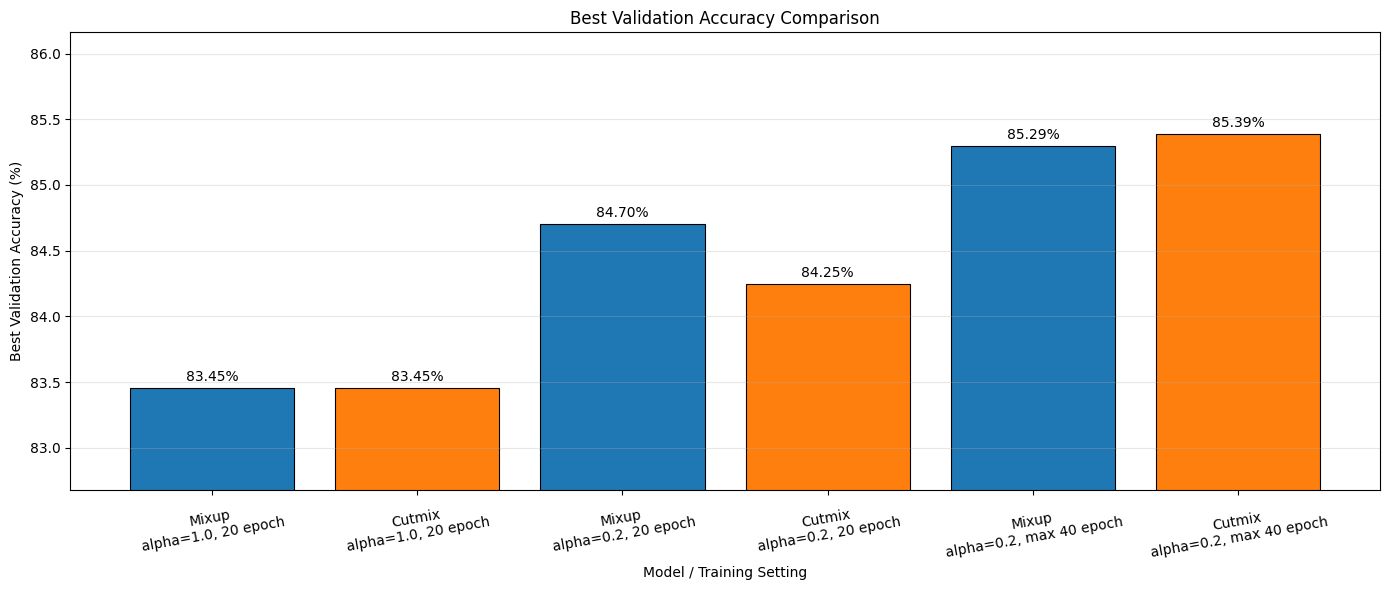

In [10]:
plot_df = comparison_table.copy()
plot_df["label"] = (
    plot_df["model"]
    + "\n"
    + plot_df["setting"].str.replace(
        ", patience=10", "", regex=False
    )
)

colors = [
    "tab:blue" if model == "Mixup" else "tab:orange"
    for model in plot_df["model"]
]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    plot_df["label"],
    plot_df["best_val_accuracy"],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)
value_min = plot_df["best_val_accuracy"].min()
value_max = plot_df["best_val_accuracy"].max()
padding = max(0.5, (value_max - value_min) * 0.4)
ax.set_ylim(value_min - padding, value_max + padding)
ax.set_title("Best Validation Accuracy Comparison")
ax.set_ylabel("Best Validation Accuracy (%)")
ax.set_xlabel("Model / Training Setting")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", labelrotation=10)

fig.tight_layout()
fig.savefig(
    RESULT_DIR / "best_val_accuracy_comparison.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 10. 결과 해석 기준

1. **20 epoch와 최대 40 epoch 비교**  
   Alpha 0.2의 40 epoch 설정이 더 높다면, 20 epoch 시점에는 아직 충분히
   수렴하지 않았을 가능성이 있습니다.

2. **Early stopping 발생 여부**  
   `early_stopped=True`이면 40 epoch를 모두 채운 것이 아니라 validation
   loss가 10회 연속 개선되지 않아 중단된 것입니다. 이는 무조건 과대적합을
   확정하는 신호라기보다, 현재 optimizer와 learning rate에서 추가 학습의
   이득이 관찰되지 않았다는 뜻입니다.

3. **Best accuracy와 best loss의 epoch 차이**  
   accuracy는 맞힌 개수만 보지만 Cross Entropy는 예측 확률까지 반영합니다.
   따라서 `best_acc_epoch`와 `best_loss_epoch`가 달라도 오류가 아닙니다.

4. **공정한 비교의 한계**  
   모델 초기값과 데이터 분할은 동일하지만 augmentation과 batch 순서에는
   확률성이 있습니다. 차이가 작다면 단일 seed 결과만으로 일반화하지 않습니다.
